In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset=pd.read_csv("student_data.csv")
dataset.head()
dataset.columns
dataset.shape
dataset.describe()
dataset.info()


<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [3]:
#Checking null and duplicate values
dataset.isnull().sum()
dataset.duplicated().sum()

np.int64(0)

In [4]:
#Unique values
dataset["school"].unique()
dataset["sex"].unique()
dataset["address"].unique()
dataset["famsize"].unique()
dataset["Pstatus"].unique()
dataset["Mjob"].unique()
dataset["Fjob"].unique()
dataset["reason"].unique()
dataset["guardian"].unique()
dataset["schoolsup"].unique()
dataset["famsup"].unique()
dataset["paid"].unique()
dataset["activities"].unique()
dataset.head()
dataset.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [5]:
#EDA
dataset["G3"].value_counts().sort_index()
dataset["G3"].mean()
dataset[["G1", "G2", "G3"]].mean()

G1    10.908861
G2    10.713924
G3    10.415190
dtype: float64

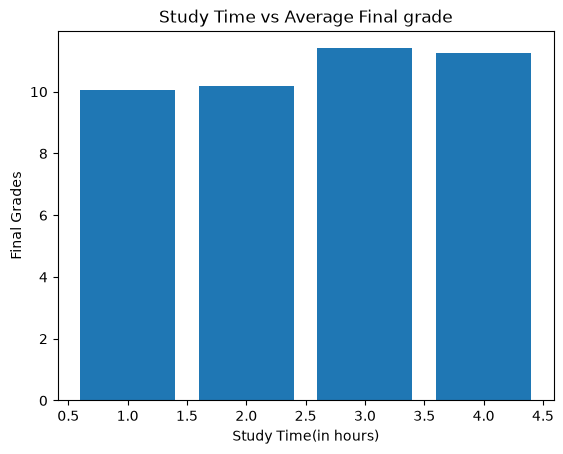

In [6]:
#Does studt Time has a relation with final grades
dataset["studytime"].value_counts().sort_index()
avg_grade=dataset.groupby("studytime")["G3"].mean()
plt.bar(avg_grade.index,avg_grade.values)
plt.title("Study Time vs Average Final grade")
plt.xlabel("Study Time(in hours)")
plt.ylabel("Final Grades")
plt.savefig("studyhours_vs_Finalgrade")
plt.show()


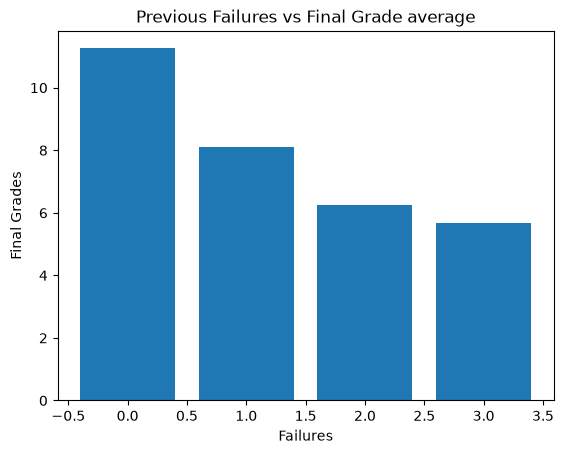

In [7]:
# Relation between previous failures and final grade
avg_failure_grade=dataset.groupby("failures")["G3"].mean()
plt.bar(avg_failure_grade.index,avg_failure_grade.values)
plt.title("Previous Failures vs Final Grade average")
plt.xlabel("Failures")
plt.ylabel("Final Grades")
plt.savefig("Previous Failures vs Average Final Grade")
plt.show()



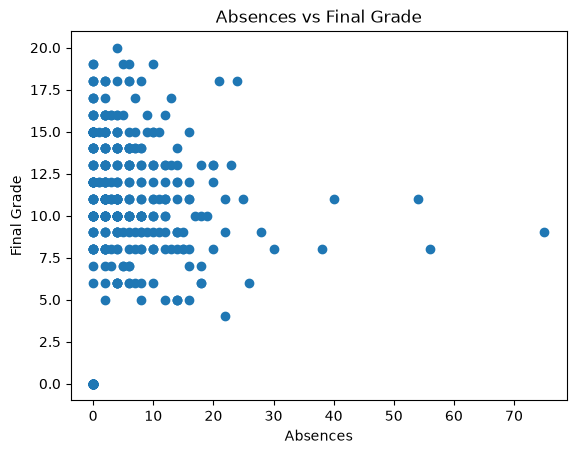

In [8]:
#Absences vs Average Final Grade
correlation=dataset["absences"].corr(dataset["G3"])
plt.scatter(dataset["absences"], dataset["G3"])
plt.title("Absences vs Final Grade")
plt.xlabel("Absences")
plt.ylabel("Final Grade")
plt.savefig("Absences_vs_final_Grade")
plt.show()

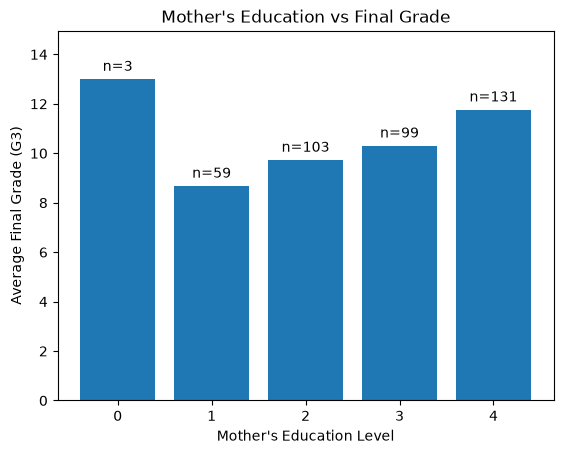

In [9]:
#Mother Education vs Final Grades
dataset["Medu"].value_counts().sort_index()
student_count = dataset["Medu"].value_counts().sort_index()
avg_grade_medu=dataset.groupby("Medu")["G3"].mean()
plt.bar(avg_grade_medu.index, avg_grade_medu.values)
for i,count in enumerate(student_count):
    avgg_grade= avg_grade_medu.values[i]
    plt.text(i, avgg_grade + 0.2, f"n={count}", ha='center', va='bottom')
plt.margins(y=0.15)

plt.xlabel("Mother's Education Level")
plt.ylabel("Average Final Grade (G3)")
plt.title("Mother's Education vs Final Grade")
plt.savefig("Mother's Education vs Final Grade")
plt.show()

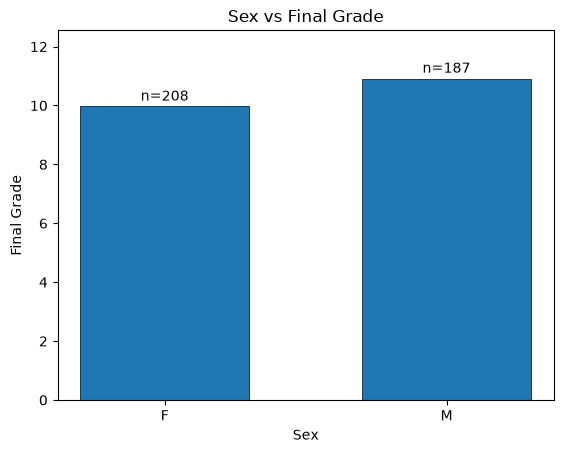

In [10]:
#Sex vs Final Grades
value_count=dataset["sex"].value_counts()
sex_relation=dataset.groupby("sex")["G3"].mean()
plt.bar(sex_relation.index,sex_relation.values,width=0.6,edgecolor="black",linewidth=0.5)
for i,count in enumerate(value_count):
    avg_grade=sex_relation.values[i]
    plt.text(i,avg_grade+0.2,f"n={count}",ha="center")
plt.margins(y=0.15)
plt.title("Sex vs Final Grade")
plt.xlabel("Sex")
plt.ylabel("Final Grade")
plt.savefig("Sex vs Final Grade")
plt.show()

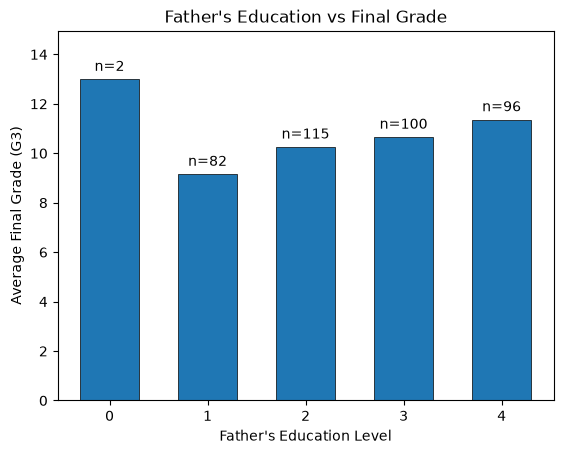

In [11]:
#FAther Education vs Final Grade
dataset["Fedu"].value_counts().sort_index()
student_count = dataset["Fedu"].value_counts().sort_index()
avg_grade_Fedu=dataset.groupby("Fedu")["G3"].mean()
plt.bar(avg_grade_Fedu.index, avg_grade_Fedu.values,edgecolor="black",linewidth=0.5,width=0.6)
for i,count in enumerate(student_count):
    avgg_grade= avg_grade_Fedu.values[i]
    plt.text(i, avgg_grade + 0.2, f"n={count}", ha='center', va='bottom')
plt.margins(y=0.15)
plt.xlabel("Father's Education Level")
plt.ylabel("Average Final Grade (G3)")
plt.title("Father's Education vs Final Grade")
plt.savefig("Father's Education vs Final Grade")
plt.show()

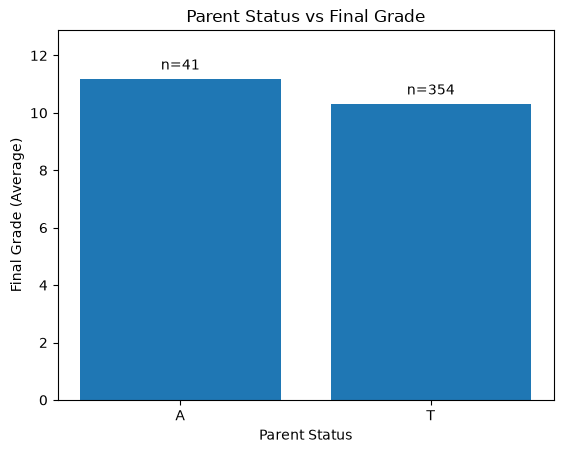

In [12]:

# Parent Status vs Final Grade
parent_status_count = dataset["Pstatus"].value_counts().sort_index()
parent_status = dataset.groupby("Pstatus")["G3"].mean().sort_index() 
plt.bar(parent_status.index, parent_status.values)
for i, count in enumerate(parent_status_count):
    avg_grade = parent_status.values[i]
    plt.text(i, avg_grade + 0.2, f"n={count}", ha='center', va='bottom')
plt.margins(y=0.15)

plt.title("Parent Status vs Final Grade")
plt.xlabel("Parent Status")
plt.ylabel("Final Grade (Average)")
plt.savefig("Parent status vs Final Grade")
plt.show()



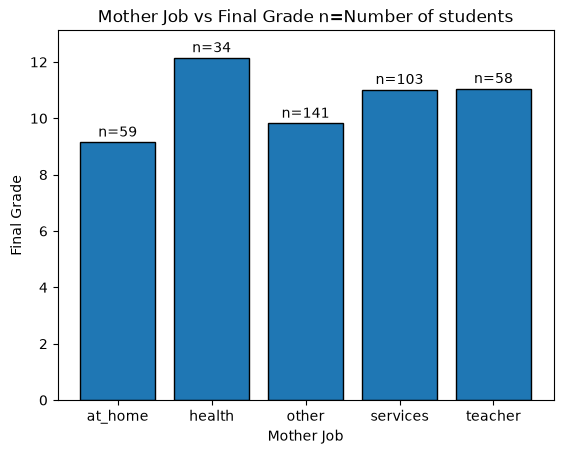

In [13]:
# Mother Job
student_count=dataset["Mjob"].value_counts().sort_index()
mother_job_effect=dataset.groupby("Mjob")["G3"].mean()
plt.bar(mother_job_effect.index,mother_job_effect.values,edgecolor="black")
for i,count in enumerate(student_count):
    yvalue=mother_job_effect.values[i]
    plt.text(i,yvalue+0.2,f"n={count}",ha="center")
plt.margins(y=0.08)
plt.title("Mother Job vs Final Grade n=Number of students")
plt.xlabel("Mother Job")
plt.ylabel("Final Grade")
plt.savefig("Mother Job vs Final grade")
plt.show()


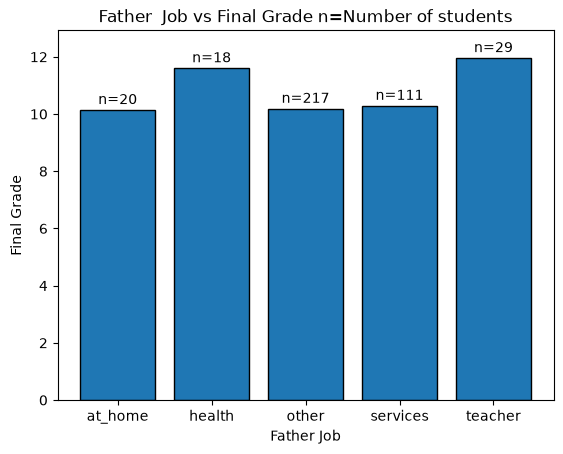

In [14]:
# Father Job vs Final Grade
student_count=dataset["Fjob"].value_counts().sort_index()
father_job_effect=dataset.groupby("Fjob")["G3"].mean()
plt.bar(father_job_effect.index,father_job_effect.values,edgecolor="black")
for i,count in enumerate(student_count):
    yvalue=father_job_effect.values[i]
    plt.text(i,yvalue+0.2,f"n={count}",ha="center")
plt.margins(y=0.08)
plt.title("Father  Job vs Final Grade n=Number of students")
plt.xlabel("Father Job")
plt.ylabel("Final Grade")
plt.savefig("Father Job vs Final grade")
plt.show()

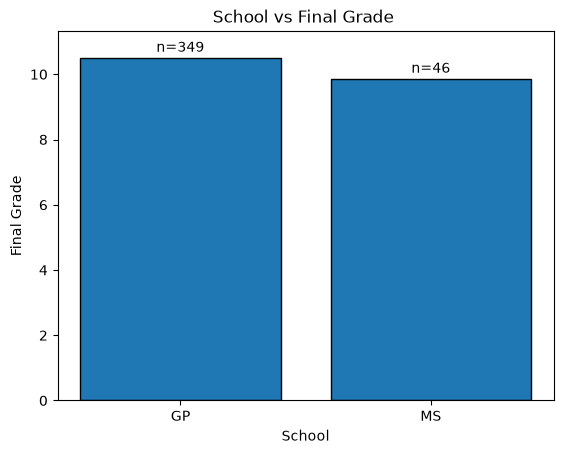

In [15]:
# Schools vs Final Grade
student_count=dataset["school"].value_counts().sort_index()
school_effect=dataset.groupby("school")["G3"].mean()
plt.bar(school_effect.index,school_effect.values,edgecolor="black")
for i,count in enumerate(student_count):
    yvalue=school_effect.values[i]
    plt.text(i,yvalue+0.2,f"n={count}",ha="center")
plt.margins(y=0.08)
plt.title("School vs Final Grade ")
plt.xlabel("School")
plt.ylabel("Final Grade")
plt.savefig("School vs Final grade")
plt.show()

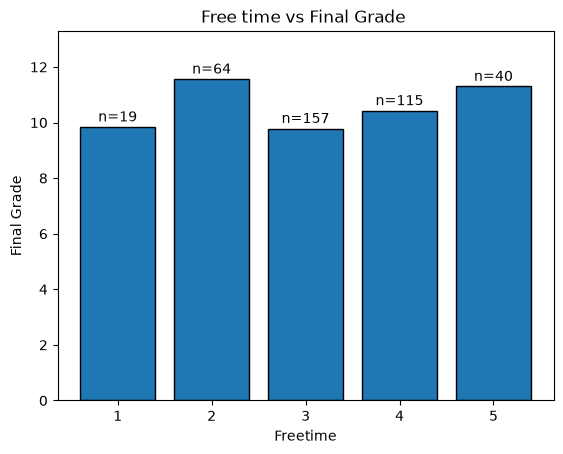

In [16]:
# Free Time vs Final Grade
student_count=dataset["freetime"].value_counts().sort_index()
freetime_effect=dataset.groupby("freetime")["G3"].mean().sort_index()
plt.bar(freetime_effect.index,freetime_effect.values,edgecolor="black")
for category,count in student_count.items():
    yvalue=freetime_effect[category]
    plt.text(category,yvalue+0.2,f"n={count}",ha="center")
plt.margins(y=0.15)

plt.title("Free time vs Final Grade ")
plt.xlabel("Freetime")
plt.ylabel("Final Grade")
plt.savefig("Freetime vs Final grade")
plt.show()

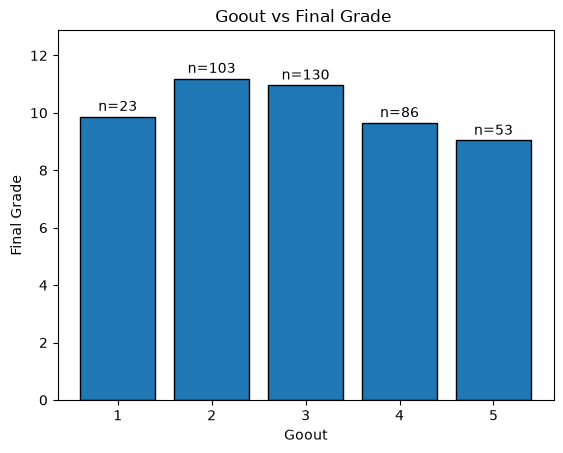

In [17]:
# Go out vs Final Grade
student_count=dataset["goout"].value_counts().sort_index()
goout_effect=dataset.groupby("goout")["G3"].mean().sort_index()
plt.bar(goout_effect.index,goout_effect.values,edgecolor="black")
for category,count in student_count.items():
    yvalue=goout_effect[category]
    plt.text(category,yvalue+0.2,f"n={count}",ha="center")
plt.margins(y=0.15)

plt.title("Goout vs Final Grade ")
plt.xlabel("Goout")
plt.ylabel("Final Grade")
plt.savefig("Goout vs Final grade")
plt.show()

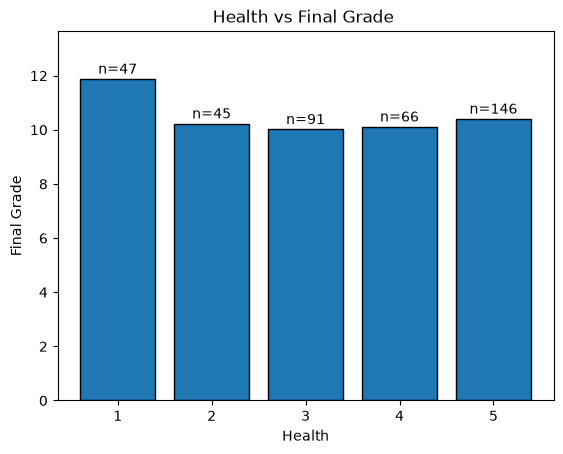

In [18]:
#Health vs Final Grade
student_count=dataset["health"].value_counts().sort_index()
health_effect=dataset.groupby("health")["G3"].mean().sort_index()
plt.bar(health_effect.index,health_effect.values,edgecolor="black")
for category,count in student_count.items():
    yvalue=health_effect[category]
    plt.text(category,yvalue+0.2,f"n={count}",ha="center")
plt.margins(y=0.15)

plt.title("Health vs Final Grade ")
plt.xlabel("Health")
plt.ylabel("Final Grade")
plt.savefig("Health vs Final grade")
plt.show()

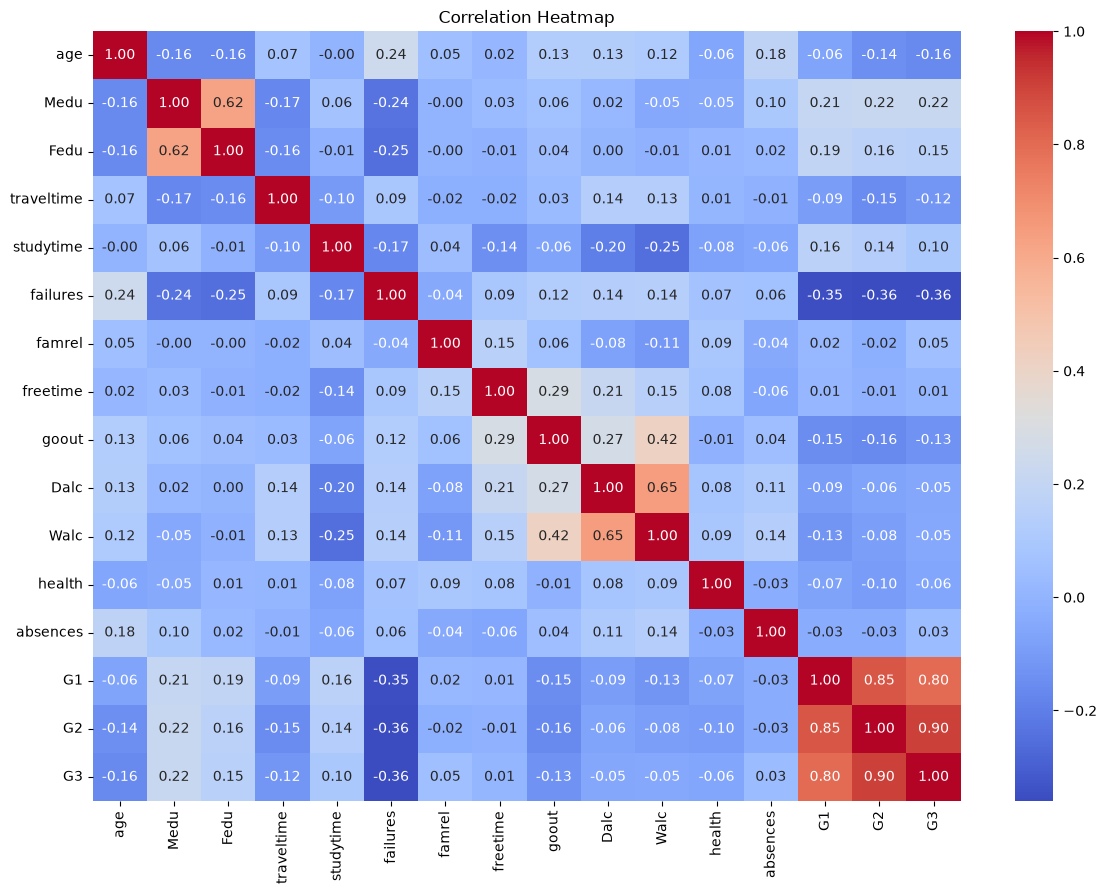

In [24]:
#Correlation
corr = dataset.select_dtypes(include="number").corr()
corr["G3"].sort_values(ascending=False)

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.savefig("Corelation Heat Map")
plt.show()

In [25]:
## Key Insights

1. G2 has the strongest positive correlation with G3 (0.905), indicating a strong relationship between second-period and final grades.

2. G1 also has a strong positive correlation with G3 (0.801).

3. Previous failures have a moderate negative correlation with G3 (-0.360).

4. Mother's education has a weak positive correlation with G3 (0.217).

5. Father's education has a weak positive correlation with G3 (0.152).

6. Study time has a very weak positive correlation with G3 (0.098).

7. Absences have almost no linear correlation with G3 (0.034).

8. Correlation shows association between variables, but it does not establish causation.


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
age,1.000000,-0.163658,-0.163438,0.070641,-0.004140,0.243665,0.053940,0.016434,0.126964,0.131125,0.117276,-0.062187,0.175230,-0.064081,-0.143474,-0.161579
Medu,-0.163658,1.000000,0.623455,-0.171639,0.064944,-0.236680,-0.003914,0.030891,0.064094,0.019834,-0.047123,-0.046878,0.100285,0.205341,0.215527,0.217147
Fedu,-0.163438,0.623455,1.000000,-0.158194,-0.009175,-0.250408,-0.001370,-0.012846,0.043105,0.002386,-0.012631,0.014742,0.024473,0.190270,0.164893,0.152457
traveltime,0.070641,-0.171639,-0.158194,1.000000,-0.100909,0.092239,-0.016808,-0.017025,0.028540,0.138325,0.134116,0.007501,-0.012944,-0.093040,-0.153198,-0.117142
studytime,-0.004140,0.064944,-0.009175,-0.100909,1.000000,-0.173563,0.039731,-0.143198,-0.063904,-0.196019,-0.253785,-0.075616,-0.062700,0.160612,0.135880,0.097820
failures,0.243665,-0.236680,-0.250408,0.092239,-0.173563,1.000000,-0.044337,0.091987,0.124561,0.136047,0.141962,0.065827,0.063726,-0.354718,-0.355896,-0.360415
famrel,0.053940,-0.003914,-0.001370,-0.016808,0.039731,-0.044337,1.000000,0.150701,0.064568,-0.077594,-0.113397,0.094056,-0.044354,0.022168,-0.018281,0.051363
freetime,0.016434,0.030891,-0.012846,-0.017025,-0.143198,0.091987,0.150701,1.000000,0.285019,0.209001,0.147822,0.075733,-0.058078,0.012613,-0.013777,0.011307
goout,0.126964,0.064094,0.043105,0.028540,-0.063904,0.124561,0.064568,0.285019,1.000000,0.266994,0.420386,-0.009577,0.044302,-0.149104,-0.162250,-0.132791
Dalc,0.131125,0.019834,0.002386,0.138325,-0.196019,0.136047,-0.077594,0.209001,0.266994,1.000000,0.647544,0.077180,0.111908,-0.094159,-0.064120,-0.054660


In [ ]:

## Conclusion

This project analyzed student performance using academic, family, social, and lifestyle-related factors.

The analysis showed that previous grades, especially G2, have the strongest relationship with the final grade (G3). Previous failures were negatively related to final performance, while parents' education and study time showed weaker positive relationships.

Some factors, such as absences, free time, health, and alcohol consumption, showed very weak linear relationships with the final grade in this dataset.

Overall, the project helped identify patterns and relationships in student performance through data cleaning, exploratory data analysis, visualization, and correlation analysis. However, these relationships do not prove that one factor directly causes changes in student performance.
